# Le lidar pour mesurer et se situer

Nous avons vu comment le robot se situe dans son environnement du point de vue d'un observateur extérieur. La tâche qui va nous occuper pendant tout le long de ce chapitre est de voir comment le robot peut se situer lui-même.

Dans un premier temps, nous nous intéressons à un instrument de mesure très utilisé pour situer les robots dans leur environnement : le **lidar**. Normalement, on devrait écrire LiDAR pour (**Li**ght **D**etection **A**nd **R**anging), mais lidar est plus facile à lire.

Ensuite, nous verrons comment le lidar peut être utilisé avec des balises afin de découvrir la position du robot en connaissant la position de la balise et la position relative du robot par rapport à la balise.


## Description sommaire du fonctionnement d'un lidar

Le but d'un lidar est de mesurer la distance des obstacles autour de celui-ci. Un lidar est un dispositif combinant plusieurs composants :
* un composant lumineux, i. e. le **laser**,
* un composant permettant de balayer l'espace à mesurer, i. e. le dispositif de **balayage optique**,
* un composant pour capter la lumière retournée, i. e. **un photodétecteur**,
* un composant élecronique pour commander les parties mécaniques et optiques et pour mesurer le temps et l'intensité lumineuse,

### Les différents composants.

#### Le laser
Le **laser** émet un rayon lumineux cohérent et polarisé dans et autour du domaine spectral visible.
La caractéristique principale du rayon lumineux est la longueur d'onde du rayon lumineux.
```{note}
LASER est à l’origine un acronyme signifiant Light Amplification by Stimulated Emission of Radiation, ou autrement, amplification de la lumière par émission stimulée de radiation. Un laser utilise le principe de l’énergie quantifiée des atomes. D’abord, il faut un milieu qui soit propice aux émissions stimulées (contraitrement aux émissions spontanées), un milieu où ces émissions pourront s’amplifier et l’élément déclencheur pour réaliser l’inversion de population (passage des atomes d’un état excité à l’état fondamental). Naturellement, les atomes dans un état excité regagnent leur état fondamental en un temps de l’ordre de 10 nanosecondes. Si un photon, qui a une énergie exactement égale à la différence entre l’énergie de l’état excité et l’énergie de l’état fondamental, atteint un atome dans un état excité, alors un autre photon de même énergie est émis et l’atome regagne son état fondamental. A l’équilibre, il y a plus d’atomes dans l’état fondamental que dans un état excité (loi de Boltzmann).
```


#### Le balayage optique

Le **balayage optique** sert à pointer le rayon lumineux dans une direction précise pour espérer avoir un retour directement dans le photodétecteur. Le dispositif peut être :
* **rotatif**, i. e. le laser tourne autour d'un axe (vertical surtout) et balaye les obstacles dans un plan horizontal,
* **MEMS** (pour [Micro-ElectroMechanical System](https://en.wikipedia.org/wiki/MEMS)), i. e. un système électronique dont la taille est de l'ordre 1 à 100 µm qui gère le mouvement d'un miroir.

#### Le photorécepteur
Le récepteur optique est placé de telle sorte que la lumière du laser, qui réfléchit sur l'obstacle, revient principalement sur lui. Alors le photorécepteur convertit le signal lumineux en signal électrique.


#### L'électronique

La mesure du temps dans un dispositif électronique se fait en comptant le nombre de cycle en sachant la durée d'un cycle.
La commande se fait au moins par un microcontrôleur.

### La rétrodiffusion
Le phénomène général qui permet à la lumière d'être renvoyée se nomme la **réflexion**. Il se trouve que le phénomène de réflexion de la lumière dans la direction d'origine existe et se nomme la **rétrodiffusion**.

### Le temps de vol
La distance entre le lidar et l'objet détecté est mesurée par le temps que met la lumière du laser à aller sur l'objet, à se réfléchir sur l'objet et à revenir sur le photorécepteur.

Soit R le robot et M l'object détecté, on démarre le chronomètre à l'instant $t_i$ et on l'arrête quand la lumière revient sur le photorécepteur à l'instant $t_f$. Dans ce laps de temps, la lumière a parcouru une distance de $d(R, M) + d(M, R)$. Le milieu traversé est l'air de l'atmosphère terrestre à basse altitude. Soit $n_{air}$ son indice de réfraction connu. La vitesse de la lumière dans ce milieu est $\frac{n_{air}}{c}$. On peut relier les grandeurs identifiées par la formule suivante : $d(R, M) + d(M, R) = \frac{n_{air}}{c} (t_f - t_i)$. Comme $d(R, M) = d(M, R)$ (on suppose que le robot et l'obstacle étaient immobiles durant la mesure), alors $d(R, M) = \frac{n_{air}(t_f - t_i)}{2c}$.

```{note}
Le principe de Fermat qui est un dérivé du principe de moindre action affirme que la lumiière emprunte le chemin le plus court. Dans le cas où l'indice de réfraction du milieu traversé reste homogène, ce qui est le cas dans des conditions normales, la lumière a une trajectoire rectiligne. Dans le vide, la lumière a une vitesse de c = 299 792 458 m/s.
Pour rappel, l'indice de réfraction d'un milieu est le rapport de la vitesse de la lumière dans le vide sur la vitesse de phase.
```

### Lidar rotatif

Le lidar qui nous intéresse est constitué d'un laser, d'un récepteur optique et d'une partie mécanique capable de tourner autour d'un axe vertical. Pour un angle donné, le lidar nous donne la distance entre le lidar et l'obstacle visible pour cet angle.

Les caractéristiques d'un tel lidar sont :
* l'intervalle de distance mesurable, (si c'est trop loin, la lumière qui revient est trop faible pour être distinguée et si c'est trop près, la lumière qui revient est trop puissante pour déterminer la distance),
* la fréquence d'échantillonage,
* la vitesse de rotation,
* la résolution angulaire,
* l'intervalle angulaire (au mieux, c'est 360°).

Le lidar nous donne accès à une version discrétise de cette fonction $\theta(t) \rightarrow \rho(\theta(t))$. Nous notons $R_N(t) = \{(\theta_i, \rho_i), i \in 1:N\}$ l'ensemble des $N$ mesures prises pour une rotation du lidar démarrée à l'instant t.

L'accès à une **rangée de points** autour du lidar nous donne la possibilité de distinguer la forme des obstacles environnants. Les balises, des obstacles choisis, sont les éléments que nous chercherons en premier. C'est ce que nous décrivons dans le paragraphe suivant.

## Visualisation

Visualisons ce qu'un lidar peut nous montrer. Plaçons-nous d'abord dans un repère polaire donc l'origine est le centre du lidar. C'est la manière la plus naturelle de montrer ce qu'un lidar a mesuré.

In [31]:
def get_05_05_2019_lidar_measures():
    """

    :param directory_name:
    :return:
    """
    import json
    import os
    from slam_robot import PACKDIR
    measures = []
    for filename in os.listdir(os.path.join(PACKDIR, "examples", "samples")):
        if filename.startswith("lidar"):
            with open(os.path.join(PACKDIR, "examples", "samples", filename), "r") as f:
                data = json.load(f)
                measures.append([[float(k) for k in j] for j in data])
    return measures

# get_05_05_2019_lidar_measures()


In [35]:
import numpy as np
theta = np.linspace(0, 2*np.pi, 100)

def polar_circle_equation(theta, minimal_distance, angle_at_minimal_distance):
    return minimal_distance/(np.cos(theta - angle_at_minimal_distance))

r = polar_circle_equation(theta, 10, 2*np.pi/3)

In [33]:
from typing import List, Union

minimum_distance = 80  # in mm
maximum_distance = 3500  # in mm

def filter_keep_good_measure(measure: List[Union[float, int]], threshold):
    return measure[2] > threshold


def keep_good_measures(turn: List, threshold: int):
    """

    :param turn: list of measures ; one measure is [angle (in rad), distance (in m), quality (from 0 to 47)]
    :param threshold:
    :return:
    """
    return [measure[:2] for measure in turn if filter_keep_good_measure(measure, threshold)]


def filter_keep_not_too_far_or_not_too_close(measure: List[float]):
    return minimum_distance < measure[1] < maximum_distance



def filter_points(one_turn: List, threshold: Union[int, float]) -> List[np.ndarray]:
    """

    :param one_turn: measures in cartesian coordinates and rotates so that angle measures are normalized
    :param threshold:
    :return:
    """
    return [np.array([np.pi/2 - np.deg2rad(measure[0]), measure[1]]) for measure in one_turn
            if filter_keep_not_too_far_or_not_too_close(measure) and
            filter_keep_good_measure(measure, threshold)]

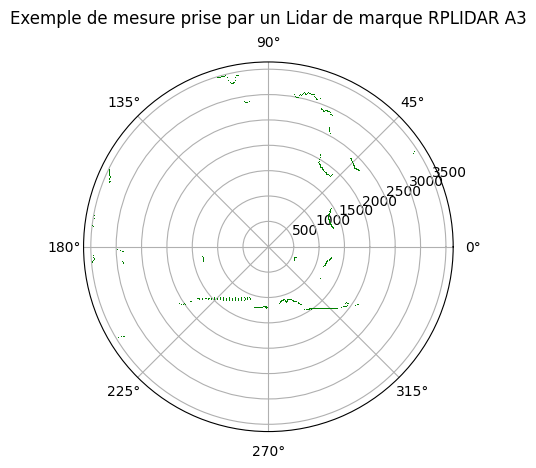

In [34]:
import matplotlib.pyplot as plt
import numpy as np

measures = get_05_05_2019_lidar_measures()[0]
measures = filter_points(measures, 100)
theta  = np.array([measure[0] for measure in measures])
r  = np.array([measure[1] for measure in measures])

ax = plt.subplot(projection="polar")
ax.plot(theta, r, "g,")
ax.set_title("A line plot on a polar axis", va='bottom')
ax.set_title("Exemple de mesure prise par un Lidar de marque RPLIDAR A3", va='bottom')
plt.show()

Le lidar étant au centre, dès qu'un obstacle est repéré par le laser, sa distance est relevée et ce pour tous les angles mesurés. Il ne peut y avoir d'obstacle relevé derrière un obstacle déjà relevé.

## Bibliographie

* [Introduction aux systèmes LiDAR (Thalès Group)](https://www.thalesgroup.com/fr/marches/aerospace/blog/lidar-comment-ca-marche) - Pour une vue d'ensemble industrielle.
* [Cours sur la navigation des robots mobiles (B. Filliat, ENSTA Paris)](https://perso.ensta.fr/~chapoutot/teaching/robotique-mobile/slides/Filliat_Navigation_ENSTAParis.pdf) - Pour l'intégration du lidar dans le SLAM.
* [RPLidar A3 - Introduction and Datasheet](https://www.slamtec.com/en/Lidar/A3) - Un exemple concret de lidar à triangulation très utilisé en robotique mobile.
* [How Lidar Works (Velodyne)](https://velodynelidar.com/what-is-lidar/) - Ressources didactiques sur le ToF et les lidars 3D/2D.
* [LiDAR - Wikipedia](https://en.wikipedia.org/wiki/Lidar) - Pour les principes physiques détaillés (rétrodiffusion, réflexion).
* [Introduction au LASER](https://femto-physique.fr/optique/pdf/presentation-laser.pdf) - Introduction aux LASER.